# Brent Crude Oil Price Forecasting and Volatility Analysis

This notebook presents a reproducible univariate study of Brent crude oil prices. It combines exploratory time-series analysis with three price-forecasting approaches—ARIMA, XGBoost, and LSTM—and a separate GARCH(1,1) model of return volatility.

The price target is the Brent price **30 observed price days ahead**, denoted by \(P_{t+30}\). The GARCH model estimates volatility **one observed price day ahead** and is evaluated separately because volatility and price level are different quantities. A naive persistence forecast provides a transparent price benchmark.

All splits preserve time order. Feature scaling, hyperparameter selection, and model fitting are restricted to information available before each evaluation period, and target-date gaps prevent overlapping future labels from crossing split boundaries.


In [1]:
# Run once in Google Colab; its standard runtime supplies the other imports below.
%pip -q install arch xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 8.4 MB/s eta 0:00:00


In [2]:
import hashlib
import os
import random
from importlib.metadata import version
from math import sqrt
from pathlib import Path

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from arch import arch_model
from IPython.display import display
from scipy.stats import pearsonr
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from xgboost import XGBRegressor

SEED = 42
HORIZON = 30

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option("display.max_columns", 100)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("statsmodels:", version("statsmodels"))
print("scikit-learn:", version("scikit-learn"))
print("xgboost:", version("xgboost"))
print("tensorflow:", tf.__version__)
print("arch:", version("arch"))


pandas: 2.2.2
numpy: 2.0.2
statsmodels: 0.14.6
scikit-learn: 1.6.1
xgboost: 3.3.0
tensorflow: 2.20.0
arch: 8.0.0


## 1. Dataset Understanding and Literature Review

### Dataset and forecasting objectives

The dataset is FRED series **DCOILBRENTEU**, Europe Brent Spot Price FOB, originally supplied by the U.S. Energy Information Administration. It is quoted in USD per barrel and published at daily frequency, with unavailable observations on holidays and some non-trading days. The fixed window is 1 January 2005 to 31 December 2025; the first available price in that window is 4 January 2005.

Brent is suitable because its long history contains trends, structural changes, irregular shocks, and volatility clustering. It supports both price forecasting and the separate GARCH requirement.

| Purpose | Target | Horizon |
|---|---|---|
| Price forecasting | Brent price \(P_{t+30}\) | 30 observed price days |
| Volatility modelling | Conditional variance/standard deviation of log returns | One observed price day |

### Recent related studies

| Study | Relevant result | Limitation motivating this notebook |
|---|---|---|
| [Ziółkowski (2024)](https://link.springer.com/chapter/10.1007/978-981-97-5934-7_15) | Compares LSTM, Prophet, and XGBoost for WTI and Brent. | A model comparison still depends strongly on horizon and validation design. |
| [Jin and Xu (2024)](https://doi.org/10.1016/j.meaene.2024.100001) | Examines neural-network forecasting across crude oil, heating oil, and natural gas prices. | Neural models require configuration and out-of-sample validation; accuracy is not guaranteed across market regimes. |
| [Jha et al. (2024)](https://doi.org/10.1016/j.energy.2024.131185) | Finds nonlinear ML useful for multivariate crude-oil forecasting. | Its richer external predictors are unavailable in this deliberately price-history-only comparison. |
| [Alruqimi and Di Persio (2024)](https://link.springer.com/article/10.1007/s44196-024-00640-3) | Demonstrates the difficulty of multi-step Brent forecasting with recurrent networks. | Hybrid ensembles add complexity and may not generalise across abrupt shocks. |
| [Chung (2024)](https://arxiv.org/abs/2405.19849) | Shows that GARCH remains informative for energy-volatility persistence alongside ML. | It is a preprint, and volatility models do not forecast price direction or level. |

The studies motivate a deliberately compact comparison: ARIMA provides an interpretable linear benchmark, XGBoost tests nonlinear relationships in engineered temporal features, LSTM tests sequential nonlinear learning, and GARCH models volatility rather than price level. Common limitations are dependence on historical patterns, sensitivity to regime changes, and limited information when exogenous market drivers are excluded.


In [3]:
# Load a fixed FRED window and preserve the first downloaded snapshot.
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU"
SNAPSHOT_PATH = Path("fred_DCOILBRENTEU_snapshot.csv")
START_DATE = pd.Timestamp("2005-01-01")
END_DATE = pd.Timestamp("2025-12-31")

snapshot_exists = SNAPSHOT_PATH.exists()
if snapshot_exists:
    raw = pd.read_csv(SNAPSHOT_PATH)
    source_used = f"local snapshot: {SNAPSHOT_PATH}"
else:
    raw = pd.read_csv(FRED_URL)
    source_used = FRED_URL

date_candidates = [c for c in raw.columns if c.lower() in {"date", "observation_date"}]
if not date_candidates or "DCOILBRENTEU" not in raw.columns:
    raise ValueError(f"Unexpected FRED columns: {raw.columns.tolist()}")

parsed_dates = pd.to_datetime(raw[date_candidates[0]], errors="coerce")
parsed_prices = pd.to_numeric(raw["DCOILBRENTEU"], errors="coerce")
window_observations = parsed_dates.between(START_DATE, END_DATE) & parsed_prices.notna()
latest_window_observation = parsed_dates.loc[window_observations].max()
minimum_acceptable_end = END_DATE - pd.Timedelta(days=7)
if pd.isna(latest_window_observation) or latest_window_observation < minimum_acceptable_end:
    raise ValueError(
        f"{source_used} does not cover the fixed analysis window through late 2025. "
        "Remove an outdated local snapshot and rerun with internet access."
    )

# Cache only a validated download; replacing the temporary file avoids a partial snapshot.
if not snapshot_exists:
    snapshot_temp = SNAPSHOT_PATH.with_suffix(".tmp")
    raw.to_csv(snapshot_temp, index=False)
    snapshot_temp.replace(SNAPSHOT_PATH)

raw = raw.rename(columns={date_candidates[0]: "date", "DCOILBRENTEU": "price"})
raw["date"] = parsed_dates
raw["price"] = parsed_prices
raw = raw.loc[raw["date"].between(START_DATE, END_DATE), ["date", "price"]]
raw = raw.dropna(subset=["date"]).drop_duplicates("date", keep="last").sort_values("date")

if (raw["price"].dropna() <= 0).any():
    raise ValueError("Non-positive prices found; log returns would be invalid.")

observed = raw.dropna(subset=["price"]).set_index("date").sort_index()
price = observed["price"].astype(float).rename("price")

snapshot_hash = hashlib.sha256(raw.to_csv(index=False).encode("utf-8")).hexdigest()
print("Source used:", source_used)
print("Filtered-data SHA256:", snapshot_hash)
print("Observed date range:", price.index.min().date(), "to", price.index.max().date())


Source used: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU
Filtered-data SHA256: 5b79068704c8b14cf8482ad3ab8dc5a53dee022731d408569960ebeba54cdda6
Observed date range: 2005-01-04 to 2025-12-31


In [4]:
# Dynamic dataset characteristics and missing-value audit.
weekday_grid = raw.set_index("date")["price"].asfreq("B")

dataset_summary = pd.DataFrame({
    "Property": [
        "FRED series",
        "Unit",
        "Published frequency",
        "Analysis start",
        "Analysis end",
        "Business-weekday rows",
        "Observed price rows",
        "Unavailable weekday rows",
        "Duplicate dates after cleaning",
        "Price forecast horizon",
        "GARCH forecast horizon",
    ],
    "Value": [
        "DCOILBRENTEU",
        "USD per barrel",
        "Daily, not seasonally adjusted",
        price.index.min().date(),
        price.index.max().date(),
        len(weekday_grid),
        len(price),
        int(weekday_grid.isna().sum()),
        int(observed.index.duplicated().sum()),
        "30 observed price days",
        "1 observed price day",
    ],
})

display(dataset_summary)
display(price.describe().to_frame("Brent price"))


,Property,Value
0,FRED series,DCOILBRENTEU
1,Unit,USD per barrel
2,Published frequency,"Daily, not seasonally adjusted"
3,Analysis start,2005-01-04
4,Analysis end,2025-12-31
5,Business-weekday rows,5478
6,Observed price rows,5315
7,Unavailable weekday rows,163
8,Duplicate dates after cleaning,0
9,Price forecast horizon,30 observed price days


,Brent price
count,5315.00000
mean,75.69247
std,23.65625
min,9.12000
25%,58.55500
50%,72.56000
75%,91.98000
max,143.95000


## 2. Time-Series Exploration and Preprocessing

Missing weekday values are audited but are **not interpolated** for modelling. They mainly represent dates without a published price; inventing intermediate prices would smooth returns and distort GARCH volatility. Price models therefore use consecutive observed price days, and the horizon is stated in those units.

Extreme returns are treated as potential real market shocks. They are flagged for analysis but retained. They are not used as a full-sample outlier feature, and no global winsorisation is applied. LSTM features are scaled robustly using training data only, while Student-t GARCH allows heavy-tailed innovations.


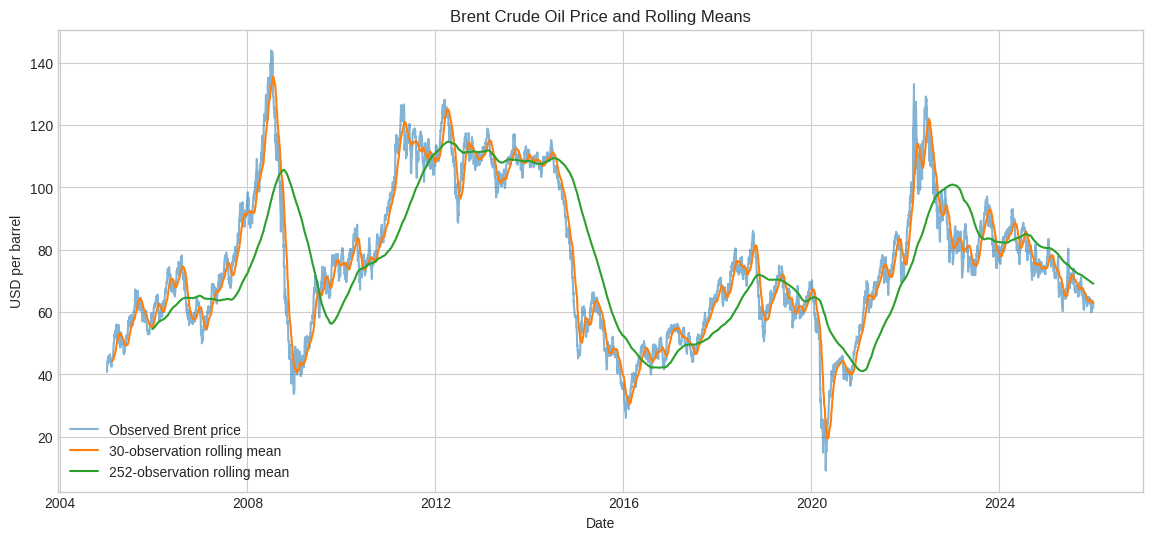

In [5]:
# Price level, short-run trend, and long-run trend.
rolling_mean_30 = price.rolling(30).mean()
rolling_mean_252 = price.rolling(252).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price.index, price, label="Observed Brent price", alpha=0.55)
ax.plot(rolling_mean_30.index, rolling_mean_30, label="30-observation rolling mean")
ax.plot(rolling_mean_252.index, rolling_mean_252, label="252-observation rolling mean")
ax.set(title="Brent Crude Oil Price and Rolling Means", xlabel="Date", ylabel="USD per barrel")
ax.legend()
plt.show()


Return observations: 5314
Modified-z outliers retained: 40


,return_pct,modified_z
date,,
2020-04-21,-64.369891,-37.706431
2020-04-22,41.202251,24.078820
2020-04-02,30.161265,17.617171
2020-03-31,-25.638944,-15.039455
2020-03-09,-25.517526,-14.968396
2020-04-09,-22.047068,-12.937338
2020-05-05,22.157369,12.932955
2020-03-18,-20.481066,-12.020848
2020-04-03,18.404931,10.736871


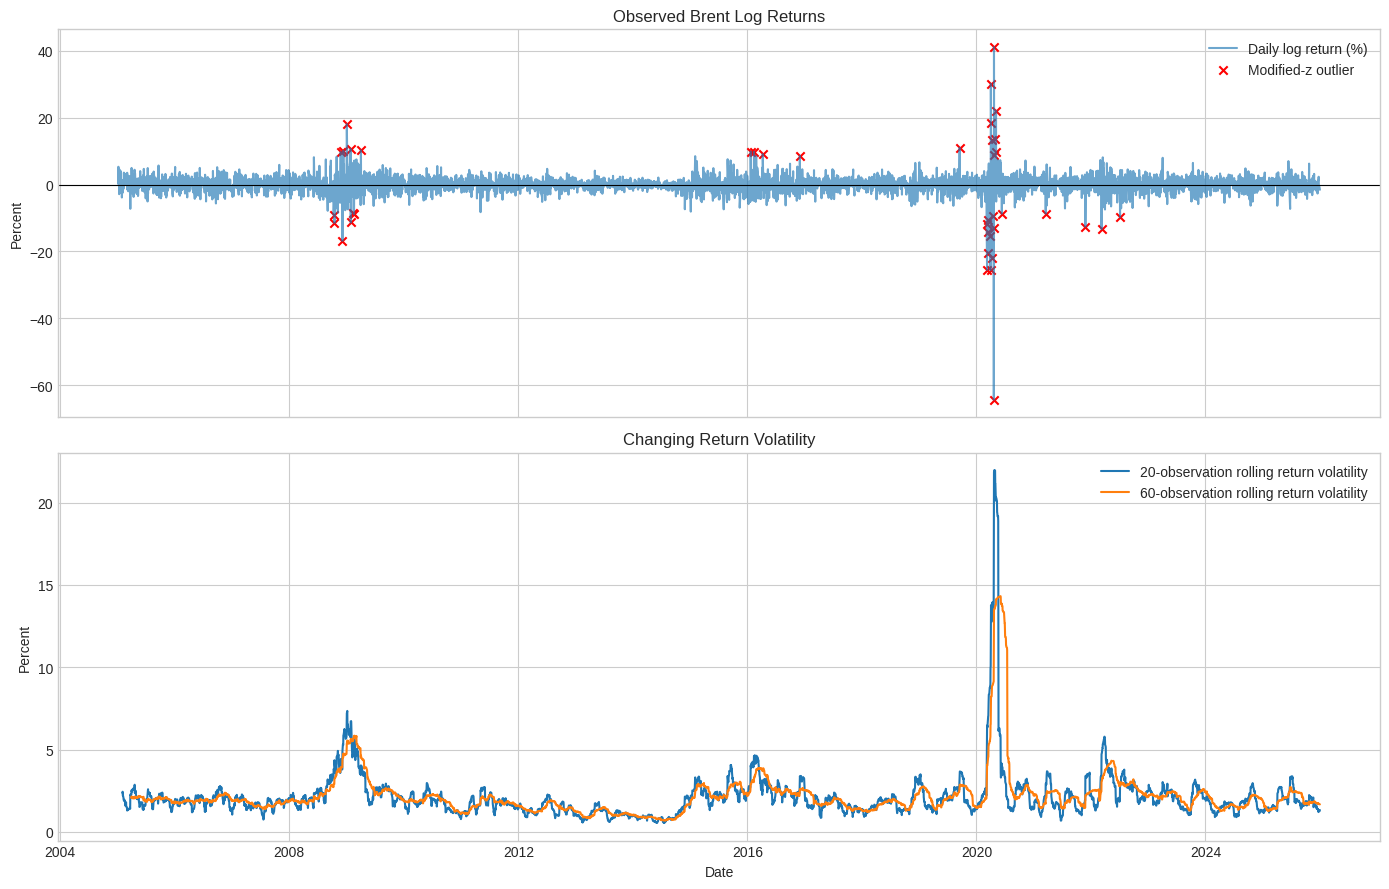

In [6]:
# Observed log returns, robust outlier flags, and rolling return volatility.
log_return_pct = (100 * np.log(price).diff()).dropna().rename("log_return_pct")

return_median = log_return_pct.median()
return_mad = np.median(np.abs(log_return_pct - return_median))
if return_mad == 0:
    modified_z = pd.Series(0.0, index=log_return_pct.index)
else:
    modified_z = 0.6745 * (log_return_pct - return_median) / return_mad

return_outlier = modified_z.abs() > 5
outlier_table = pd.DataFrame({
    "return_pct": log_return_pct,
    "modified_z": modified_z,
}).loc[return_outlier]

print("Return observations:", len(log_return_pct))
print("Modified-z outliers retained:", int(return_outlier.sum()))
display(outlier_table.reindex(outlier_table["modified_z"].abs().sort_values(ascending=False).index).head(15))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(log_return_pct.index, log_return_pct, alpha=0.65, label="Daily log return (%)")
axes[0].scatter(
    log_return_pct.index[return_outlier],
    log_return_pct.loc[return_outlier],
    marker="x",
    color="red",
    label="Modified-z outlier",
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Observed Brent Log Returns", ylabel="Percent")
axes[0].legend()

axes[1].plot(log_return_pct.rolling(20).std(), label="20-observation rolling return volatility")
axes[1].plot(log_return_pct.rolling(60).std(), label="60-observation rolling return volatility")
axes[1].set(title="Changing Return Volatility", xlabel="Date", ylabel="Percent")
axes[1].legend()
plt.tight_layout()
plt.show()


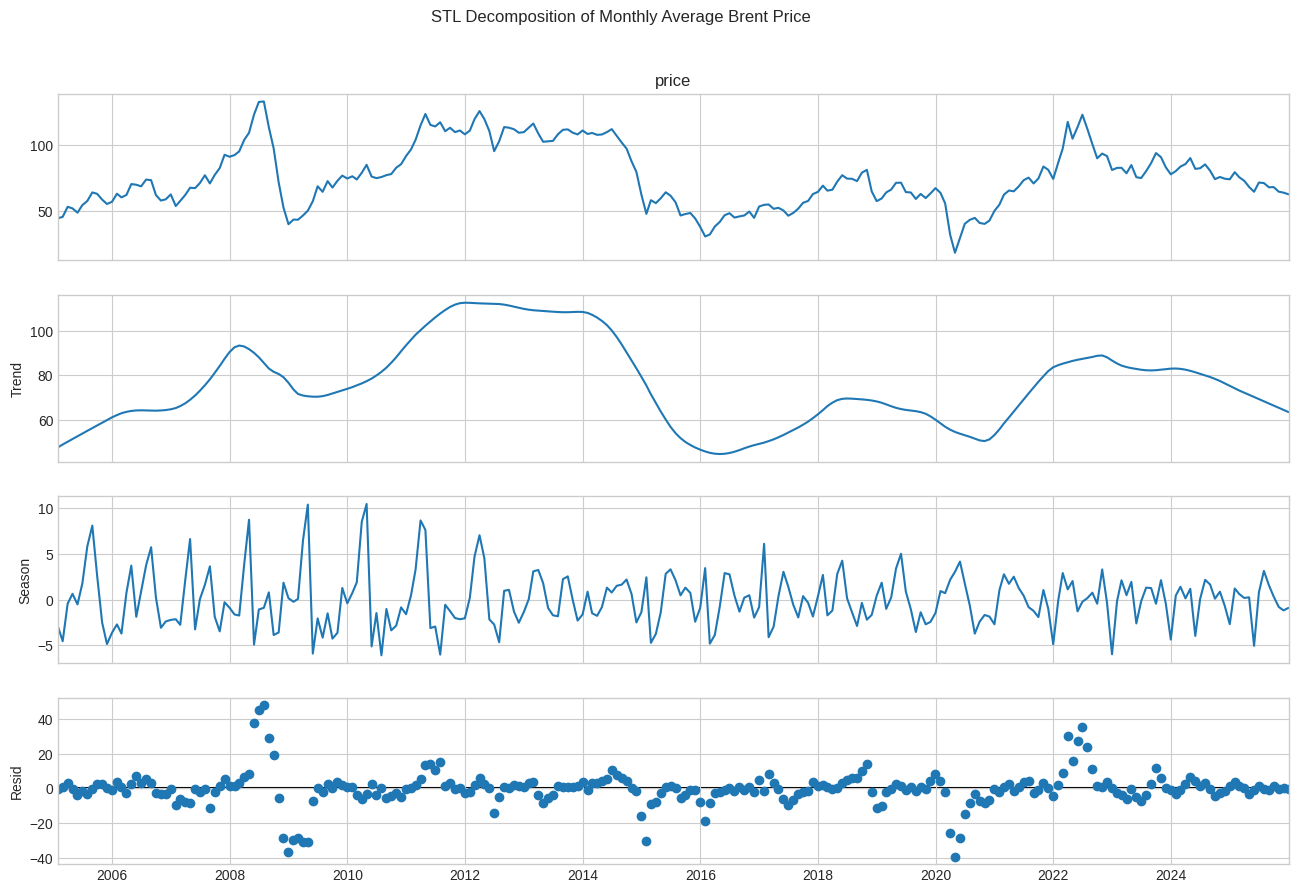

,standard deviation
trend_std,18.994225
seasonal_std,2.936486
residual_std,10.251034


In [7]:
# STL decomposition of regular monthly average prices (annual seasonal period = 12).
monthly_price = price.resample(pd.offsets.MonthEnd()).mean().dropna()
stl_result = STL(monthly_price, period=12, robust=True).fit()

fig = stl_result.plot()
fig.set_size_inches(14, 9)
fig.suptitle("STL Decomposition of Monthly Average Brent Price", y=1.02)
plt.show()

component_scale = pd.Series({
    "trend_std": stl_result.trend.std(),
    "seasonal_std": stl_result.seasonal.std(),
    "residual_std": stl_result.resid.std(),
})
display(component_scale.to_frame("standard deviation"))


In [8]:
# Causal temporal features and the direct 30-observed-price-day target.
features = pd.DataFrame(index=price.index)
features["price_t"] = price
features["return_t"] = log_return_pct.reindex(price.index)

for lag in [1, 2, 5, 10, 20, 30, 60]:
    features[f"price_lag_{lag}"] = price.shift(lag)

for lag in [1, 2, 5, 10, 20]:
    features[f"return_lag_{lag}"] = log_return_pct.shift(lag)

for window in [5, 20, 60]:
    features[f"price_rolling_mean_{window}"] = price.rolling(window).mean()
    features[f"return_rolling_std_{window}"] = log_return_pct.rolling(window).std()

month = features.index.month
day_of_year = features.index.dayofyear
features["month_sin"] = np.sin(2 * np.pi * month / 12)
features["month_cos"] = np.cos(2 * np.pi * month / 12)
features["dayofyear_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
features["dayofyear_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

features["target_price"] = price.shift(-HORIZON)
features["target_date"] = pd.Series(price.index, index=price.index).shift(-HORIZON)

feature_cols = [c for c in features.columns if c not in {"target_price", "target_date"}]
model_df = features.dropna(subset=feature_cols + ["target_price", "target_date"]).copy()
model_df["target_date"] = pd.to_datetime(model_df["target_date"])

print("Model rows:", len(model_df))
print("Predictor count:", len(feature_cols))
print("Origin range:", model_df.index.min().date(), "to", model_df.index.max().date())
print("Target range:", model_df["target_date"].min().date(), "to", model_df["target_date"].max().date())
display(model_df.head())


Model rows: 5225
Predictor count: 24
Origin range: 2005-03-30 to 2025-11-17
Target range: 2005-05-11 to 2025-12-31


,price_t,return_t,price_lag_1,price_lag_2,price_lag_5,price_lag_10,price_lag_20,price_lag_30,price_lag_60,return_lag_1,return_lag_2,return_lag_5,return_lag_10,return_lag_20,price_rolling_mean_5,return_rolling_std_5,price_rolling_mean_20,return_rolling_std_20,price_rolling_mean_60,return_rolling_std_60,month_sin,month_cos,dayofyear_sin,dayofyear_cos,target_price,target_date
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-03-30,50.63,-1.548292,51.42,51.75,55.39,53.97,50.47,44.91,40.75,-0.639723,-1.152751,-0.719557,0.538784,0.675947,51.534,3.278769,53.2305,2.282582,47.900167,2.066964,1.000000,6.123234e-17,0.999209,0.039770,48.91,2005-05-11
2005-03-31,53.22,4.988998,50.63,51.42,51.52,54.61,51.05,45.42,41.00,-1.548292,-0.639723,-7.242899,1.178868,1.142644,51.874,2.714394,53.3390,2.531033,48.103833,2.151457,1.000000,6.123234e-17,0.999745,0.022576,47.40,2005-05-12
2005-04-01,54.14,1.713902,53.22,50.63,52.35,56.03,52.89,45.42,43.25,4.988998,-1.548292,1.598186,2.567025,3.540874,52.232,2.724980,53.4015,2.435589,48.285333,2.060228,0.866025,-5.000000e-01,0.999986,0.005376,46.85,2005-05-13
2005-04-04,55.92,3.234881,54.14,53.22,51.75,55.97,52.10,45.86,43.28,1.713902,4.988998,-1.152751,-0.107143,-1.504934,53.066,2.696604,53.5925,2.499252,48.496000,2.092565,0.866025,-5.000000e-01,0.998932,-0.046215,46.42,2005-05-16
2005-04-05,54.53,-2.517109,55.92,54.14,51.42,55.79,51.87,46.09,44.71,3.234881,1.713902,-0.639723,-0.322119,-0.442436,53.688,3.167337,53.7255,2.575919,48.659667,2.093136,0.866025,-5.000000e-01,0.997989,-0.063391,47.31,2005-05-17


In [9]:
# Augmented Dickey-Fuller tests: H0 is a unit root/non-stationarity.
def adf_row(series, name):
    clean = pd.Series(series).dropna()
    result = adfuller(clean, autolag="AIC")
    return {
        "Series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "Used lags": result[2],
        "Observations": result[3],
        "Decision at 5%": "Reject unit-root H0" if result[1] < 0.05 else "Fail to reject H0",
    }

price_diff = price.diff().dropna()
adf_results = pd.DataFrame([
    adf_row(price, "Price level"),
    adf_row(price_diff, "First difference"),
    adf_row(log_return_pct, "Log return (%)"),
])
display(adf_results)


,Series,ADF statistic,p-value,Used lags,Observations,Decision at 5%
0,Price level,-2.527916,1.088289e-01,6,5308,Fail to reject H0
1,First difference,-31.371432,0.000000e+00,5,5308,Reject unit-root H0
2,Log return (%),-11.958073,4.164261e-22,32,5281,Reject unit-root H0


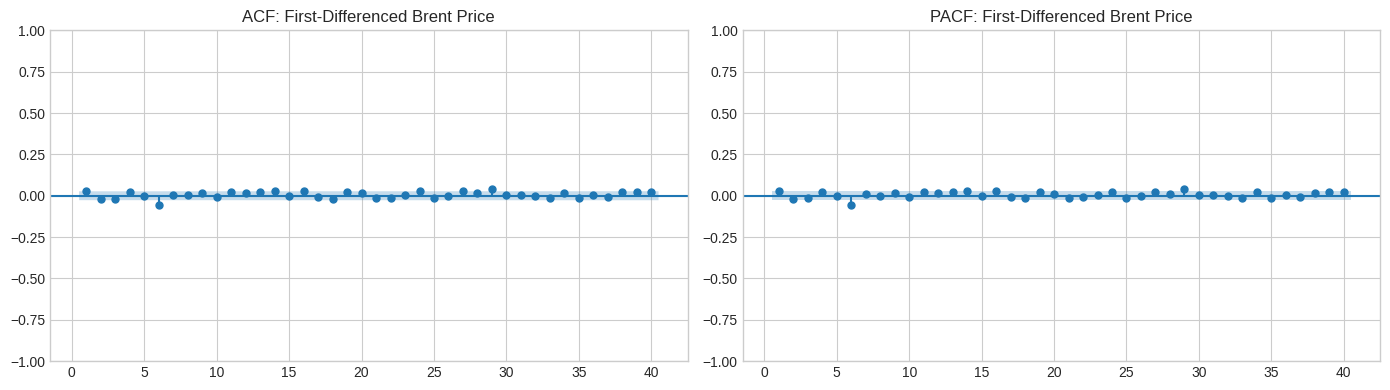

In [10]:
# Course-aligned ACF/PACF diagnostics for the differenced price series.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(price_diff, lags=40, zero=False, ax=axes[0])
plot_pacf(price_diff, lags=40, zero=False, method="ywm", ax=axes[1])
axes[0].set_title("ACF: First-Differenced Brent Price")
axes[1].set_title("PACF: First-Differenced Brent Price")
plt.tight_layout()
plt.show()


### Diagnostic interpretation

The rolling means and STL decomposition show substantial time-varying trend and irregular movement. The component standard deviations are 18.994 for trend, 10.251 for the residual, and 2.936 for seasonality, so the seasonal component is comparatively weak.

The ADF test fails to reject a unit root in the price level (statistic -2.528, \(p=0.109\)), while the first difference and log return both reject the null. Their stationarity is consistent with the near-zero short-memory pattern in the differenced-series ACF and PACF. Both \(d=0\) and \(d=1\) are nevertheless retained in the forecasting grid, with the final ARIMA order chosen by chronological validation rather than by the ADF result alone. A selected \(d=0\) model must therefore be interpreted as a forecasting approximation, not as evidence that the price level is stationary.


## 3. Traditional, Machine-Learning, and Deep-Learning Forecasts

All price models predict the same target, \(P_{t+30}\), from the same forecast origins. The outer split is chronological and purged: a training label must occur before validation begins, and a validation label must occur before testing begins. XGBoost cross-validation also uses a 30-row gap. Preprocessing and tuning never use test data.

The price-model suite is:

- **ARIMA** — traditional statistical forecasting;
- **XGBoost** — machine-learning forecasting with temporal features;
- **LSTM** — deep-learning sequence forecasting.

The naive persistence forecast is a diagnostic comparator, not a replacement for any required category.


In [11]:
# Shared required evaluation metrics.
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if np.any(y_true == 0):
        raise ValueError("MAPE is undefined when an actual value is zero.")
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def evaluate_price_predictions(model_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mape(y_true, y_pred),
    }


In [12]:
# Purged chronological 70%/15%/15% origin split.
n_rows = len(model_df)
validation_start = model_df.index[int(n_rows * 0.70)]
test_start = model_df.index[int(n_rows * 0.85)]

train_df = model_df.loc[
    (model_df.index < validation_start)
    & (model_df["target_date"] < validation_start)
].copy()

validation_df = model_df.loc[
    (model_df.index >= validation_start)
    & (model_df.index < test_start)
    & (model_df["target_date"] < test_start)
].copy()

test_df = model_df.loc[model_df.index >= test_start].copy()

# After tuning, every pre-test label whose target is before testing may be used.
train_validation_df = model_df.loc[
    (model_df.index < test_start)
    & (model_df["target_date"] < test_start)
].copy()

assert train_df["target_date"].max() < validation_df.index.min()
assert validation_df["target_date"].max() < test_df.index.min()
assert train_validation_df["target_date"].max() < test_df.index.min()

split_summary = pd.DataFrame([
    {
        "Split": name,
        "Rows": len(frame),
        "Origin start": frame.index.min().date(),
        "Origin end": frame.index.max().date(),
        "Latest target": frame["target_date"].max().date(),
    }
    for name, frame in [
        ("Training", train_df),
        ("Validation", validation_df),
        ("Test", test_df),
    ]
])
display(split_summary)

X_train = train_df[feature_cols]
y_train = train_df["target_price"]
X_validation = validation_df[feature_cols]
y_validation = validation_df["target_price"]
X_test = test_df[feature_cols]
y_test = test_df["target_price"]


,Split,Rows,Origin start,Origin end,Latest target
0,Training,3627,2005-03-30,2019-07-29,2019-09-09
1,Validation,754,2019-09-10,2022-08-26,2022-10-11
2,Test,784,2022-10-12,2025-11-17,2025-12-31


In [13]:
# Naive persistence baseline: P(t+30) = P(t).
naive_test_pred = pd.Series(test_df["price_t"].to_numpy(), index=test_df.index, name="Naive")
naive_test_metrics = evaluate_price_predictions("Naive", y_test, naive_test_pred)
display(pd.DataFrame([naive_test_metrics]))


,Model,MAE,RMSE,MAPE (%)
0,Naive,5.288418,6.588197,6.788647


### 3.1 Traditional model — ARIMA

ADF and ACF/PACF provide diagnostic guidance, while a compact parameter grid is selected by rolling-origin validation RMSE. At each origin, the model receives observed prices only through that origin and its 30th forecast step is evaluated against \(P_{t+30}\). The `SARIMAX` class is used as the statsmodels implementation, but the model is labelled ARIMA because no exogenous regressors or seasonal terms are supplied.


In [14]:
def rolling_arima_forecast(price_series, origin_dates, order, horizon=30, trend="c"):
    origin_dates = pd.DatetimeIndex(origin_dates).sort_values()
    origin_positions = price_series.index.get_indexer(origin_dates)
    if (origin_positions < 0).any():
        raise ValueError("Every ARIMA origin must exist in the observed price index.")

    first_position = int(origin_positions[0])
    initial_history = price_series.iloc[:first_position].to_numpy()
    if len(initial_history) < 200:
        raise ValueError("Insufficient initial history for ARIMA.")

    fitted = SARIMAX(
        initial_history,
        order=order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)

    predictions = []
    current_position = first_position - 1

    for origin_position, origin_date in zip(origin_positions, origin_dates):
        new_observations = price_series.iloc[current_position + 1 : origin_position + 1].to_numpy()
        if len(new_observations):
            try:
                fitted = fitted.append(new_observations, refit=False)
            except Exception:
                updated_model = SARIMAX(
                    price_series.iloc[: origin_position + 1].to_numpy(),
                    order=order,
                    trend=trend,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fitted = updated_model.filter(fitted.params)

        forecast = np.asarray(fitted.forecast(steps=horizon), dtype=float)
        predictions.append(float(forecast[-1]))
        current_position = int(origin_position)

    return pd.Series(predictions, index=origin_dates, name="ARIMA")


In [15]:
# Small course-aligned ParameterGrid, including d=0 and d=1.
arima_grid = list(ParameterGrid({
    "p": [0, 1, 2],
    "d": [0, 1],
    "q": [0, 1],
}))

# Evenly spaced rolling validation origins keep runtime practical and transparent.
validation_sample_positions = np.unique(
    np.linspace(0, len(validation_df) - 1, num=min(30, len(validation_df)), dtype=int)
)
arima_validation_origins = validation_df.index[validation_sample_positions]

arima_tuning_rows = []
for params in arima_grid:
    order = (params["p"], params["d"], params["q"])
    try:
        prediction = rolling_arima_forecast(
            price,
            arima_validation_origins,
            order=order,
            horizon=HORIZON,
            trend="c",
        )
        metrics = evaluate_price_predictions(
            f"ARIMA{order}",
            model_df.loc[prediction.index, "target_price"],
            prediction,
        )
        metrics["order"] = order
        metrics["status"] = "ok"
    except Exception as exc:
        metrics = {
            "Model": f"ARIMA{order}",
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE (%)": np.nan,
            "order": order,
            "status": f"failed: {type(exc).__name__}: {str(exc)[:120]}",
        }
    arima_tuning_rows.append(metrics)

arima_tuning_df = pd.DataFrame(arima_tuning_rows).sort_values("RMSE", na_position="last")
display(arima_tuning_df)

successful_arima = arima_tuning_df.dropna(subset=["RMSE"])
if successful_arima.empty:
    raise RuntimeError("Every ARIMA candidate failed. Inspect the displayed warnings/errors.")

best_arima_order = tuple(successful_arima.iloc[0]["order"])
print("Selected ARIMA order:", best_arima_order)


,Model,MAE,RMSE,MAPE (%),order,status
4,"ARIMA(2, 0, 0)",8.737044,10.775706,18.332506,"(2, 0, 0)",ok
3,"ARIMA(1, 0, 1)",8.744305,10.781059,18.315324,"(1, 0, 1)",ok
2,"ARIMA(1, 0, 0)",8.746764,10.786340,18.330306,"(1, 0, 0)",ok
5,"ARIMA(2, 0, 1)",8.791590,10.810343,18.299673,"(2, 0, 1)",ok
8,"ARIMA(1, 1, 0)",9.030414,11.018371,18.393570,"(1, 1, 0)",ok
7,"ARIMA(0, 1, 1)",9.032133,11.019152,18.391773,"(0, 1, 1)",ok
9,"ARIMA(1, 1, 1)",9.034605,11.022106,18.393397,"(1, 1, 1)",ok
6,"ARIMA(0, 1, 0)",9.037266,11.024671,18.405463,"(0, 1, 0)",ok
10,"ARIMA(2, 1, 0)",9.036765,11.024853,18.398829,"(2, 1, 0)",ok
11,"ARIMA(2, 1, 1)",9.037090,11.025213,18.399533,"(2, 1, 1)",ok


Selected ARIMA order: (2, 0, 0)


In [16]:
# Final rolling-origin ARIMA evaluation on every test origin.
arima_test_pred = rolling_arima_forecast(
    price,
    test_df.index,
    order=best_arima_order,
    horizon=HORIZON,
    trend="c",
)
arima_test_metrics = evaluate_price_predictions("ARIMA", y_test, arima_test_pred)
display(pd.DataFrame([arima_test_metrics]))


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,5.222848,6.418845,6.730894


### 3.2 Machine-learning model — XGBoost

XGBoost uses the engineered lag, rolling, return, and cyclical seasonal features. Hyperparameters are tuned only inside the training period with `TimeSeriesSplit(gap=30)`, which prevents a fold's 30-step labels from overlapping its validation origins. The chosen estimator is then refitted on all eligible pre-test rows.


In [17]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=SEED,
    n_jobs=1,
)

xgb_param_distributions = {
    "n_estimators": [150, 250, 400, 600],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [1.0, 2.0],
}

xgb_cv = TimeSeriesSplit(n_splits=4, gap=HORIZON)

# Explicitly verify the target-date separation in every CV fold.
for fold_number, (train_idx, validation_idx) in enumerate(xgb_cv.split(X_train), start=1):
    fold_train = train_df.iloc[train_idx]
    fold_validation = train_df.iloc[validation_idx]
    assert fold_train["target_date"].max() < fold_validation.index.min()
    print(
        f"Fold {fold_number}: train target through {fold_train['target_date'].max().date()} | "
        f"validation origins from {fold_validation.index.min().date()}"
    )

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=xgb_cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)
xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:", xgb_search.best_params_)
print("Best purged-CV RMSE:", -xgb_search.best_score_)

xgb_validation_pred = xgb_search.best_estimator_.predict(X_validation)
xgb_validation_metrics = evaluate_price_predictions(
    "XGBoost validation",
    y_validation,
    xgb_validation_pred,
)
display(pd.DataFrame([xgb_validation_metrics]))

final_xgb = clone(xgb_search.best_estimator_)
final_xgb.fit(train_validation_df[feature_cols], train_validation_df["target_price"])
xgb_test_pred = pd.Series(final_xgb.predict(X_test), index=test_df.index, name="XGBoost")
xgb_test_metrics = evaluate_price_predictions("XGBoost", y_test, xgb_test_pred)
display(pd.DataFrame([xgb_test_metrics]))


Fold 1: train target through 2008-02-06 | validation origins from 2008-02-07
Fold 2: train target through 2010-12-21 | validation origins from 2010-12-22
Fold 3: train target through 2013-11-14 | validation origins from 2013-11-15
Fold 4: train target through 2016-09-21 | validation origins from 2016-09-22
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best XGBoost parameters: {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best purged-CV RMSE: 13.03479906471632


,Model,MAE,RMSE,MAPE (%)
0,XGBoost validation,10.90885,15.183201,21.104055


,Model,MAE,RMSE,MAPE (%)
0,XGBoost,6.089865,7.985189,7.831448


### 3.3 Deep-learning model — LSTM

Sequential inputs are represented by a fixed lookback window. A compact grid varies lookback, hidden units, dropout, learning rate, and batch size. During tuning, robust feature scaling and target scaling are fitted on training data only; validation is chronological and `shuffle=False`. The selected configuration is rebuilt from scratch, its scalers are refitted using eligible pre-test data only, and the final epoch count is fixed before test evaluation.


In [18]:
def make_lstm_sequences(X_scaled, y_scaled, all_dates, eligible_origins, lookback):
    eligible = set(pd.DatetimeIndex(eligible_origins))
    X_seq, y_seq, dates = [], [], []

    for end_position in range(lookback - 1, len(all_dates)):
        origin = all_dates[end_position]
        if origin not in eligible:
            continue
        start_position = end_position - lookback + 1
        X_seq.append(X_scaled[start_position : end_position + 1])
        y_seq.append(y_scaled[end_position])
        dates.append(origin)

    return np.asarray(X_seq), np.asarray(y_seq), pd.DatetimeIndex(dates)


def build_lstm_model(input_shape, units, dropout, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )
    return model


def scaled_lstm_data(fit_frame, target_origins):
    feature_scaler = RobustScaler()
    target_scaler = MinMaxScaler()
    feature_scaler.fit(fit_frame[feature_cols])
    target_scaler.fit(fit_frame[["target_price"]])

    X_scaled = feature_scaler.transform(model_df[feature_cols])
    target_origins = pd.DatetimeIndex(target_origins)
    target_positions = model_df.index.get_indexer(target_origins)
    if np.any(target_positions < 0):
        raise ValueError("Every LSTM target origin must exist in model_df.")
    y_scaled = np.full(len(model_df), np.nan)
    y_scaled[target_positions] = target_scaler.transform(
        model_df.loc[target_origins, ["target_price"]]
    ).ravel()
    return feature_scaler, target_scaler, X_scaled, y_scaled


In [19]:
# Compact manual LSTM tuning grid.
lstm_configs = [
    {"lookback": 30, "units": 32, "dropout": 0.10, "learning_rate": 0.0010, "batch_size": 32},
    {"lookback": 60, "units": 32, "dropout": 0.10, "learning_rate": 0.0010, "batch_size": 32},
    {"lookback": 30, "units": 64, "dropout": 0.20, "learning_rate": 0.0005, "batch_size": 64},
    {"lookback": 60, "units": 64, "dropout": 0.20, "learning_rate": 0.0005, "batch_size": 64},
]

tuning_target_origins = train_df.index.append(validation_df.index)
_, tuning_target_scaler, X_scaled_tuning, y_scaled_tuning = scaled_lstm_data(
    train_df,
    tuning_target_origins,
)
all_model_dates = model_df.index
lstm_tuning_rows = []

for config in lstm_configs:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    X_lstm_train, y_lstm_train, _ = make_lstm_sequences(
        X_scaled_tuning,
        y_scaled_tuning,
        all_model_dates,
        train_df.index,
        config["lookback"],
    )
    X_lstm_validation, y_lstm_validation, validation_dates = make_lstm_sequences(
        X_scaled_tuning,
        y_scaled_tuning,
        all_model_dates,
        validation_df.index,
        config["lookback"],
    )

    model = build_lstm_model(
        input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2]),
        units=config["units"],
        dropout=config["dropout"],
        learning_rate=config["learning_rate"],
    )
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    history = model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(X_lstm_validation, y_lstm_validation),
        epochs=40,
        batch_size=config["batch_size"],
        shuffle=False,
        verbose=0,
        callbacks=[early_stopping],
    )

    validation_pred_scaled = model.predict(X_lstm_validation, verbose=0)
    validation_pred = tuning_target_scaler.inverse_transform(validation_pred_scaled).ravel()
    validation_actual = model_df.loc[validation_dates, "target_price"].to_numpy()
    metrics = evaluate_price_predictions("LSTM", validation_actual, validation_pred)
    metrics.update(config)
    metrics["best_epoch"] = int(np.argmin(history.history["val_loss"]) + 1)
    lstm_tuning_rows.append(metrics)

lstm_tuning_df = pd.DataFrame(lstm_tuning_rows).sort_values("RMSE")
display(lstm_tuning_df)

best_lstm = lstm_tuning_df.iloc[0].to_dict()
print("Selected LSTM configuration:", {
    key: best_lstm[key]
    for key in ["lookback", "units", "dropout", "learning_rate", "batch_size", "best_epoch"]
})


,Model,MAE,RMSE,MAPE (%),lookback,units,dropout,learning_rate,batch_size,best_epoch
1,LSTM,11.797665,15.043142,23.704857,60,32,0.1,0.0010,32,15
0,LSTM,12.274692,15.403382,24.682828,30,32,0.1,0.0010,32,6
3,LSTM,14.161668,17.741161,27.599924,60,64,0.2,0.0005,64,13
2,LSTM,14.332954,18.373362,27.473250,30,64,0.2,0.0005,64,18


Selected LSTM configuration: {'lookback': 60, 'units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 32, 'best_epoch': 15}


In [20]:
# Rebuild and train the selected LSTM on eligible pre-test data only.
_, final_target_scaler, X_scaled_final, y_scaled_final = scaled_lstm_data(
    train_validation_df,
    train_validation_df.index,
)

best_lookback = int(best_lstm["lookback"])
X_lstm_train_validation, y_lstm_train_validation, _ = make_lstm_sequences(
    X_scaled_final,
    y_scaled_final,
    all_model_dates,
    train_validation_df.index,
    best_lookback,
)
X_lstm_test, _, lstm_test_dates = make_lstm_sequences(
    X_scaled_final,
    y_scaled_final,
    all_model_dates,
    test_df.index,
    best_lookback,
)

assert lstm_test_dates.equals(test_df.index)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
final_lstm = build_lstm_model(
    input_shape=(X_lstm_train_validation.shape[1], X_lstm_train_validation.shape[2]),
    units=int(best_lstm["units"]),
    dropout=float(best_lstm["dropout"]),
    learning_rate=float(best_lstm["learning_rate"]),
)
final_lstm.fit(
    X_lstm_train_validation,
    y_lstm_train_validation,
    epochs=int(best_lstm["best_epoch"]),
    batch_size=int(best_lstm["batch_size"]),
    shuffle=False,
    verbose=0,
)

lstm_test_pred_scaled = final_lstm.predict(X_lstm_test, verbose=0)
lstm_test_pred = pd.Series(
    final_target_scaler.inverse_transform(lstm_test_pred_scaled).ravel(),
    index=lstm_test_dates,
    name="LSTM",
)
lstm_test_metrics = evaluate_price_predictions("LSTM", y_test, lstm_test_pred)
display(pd.DataFrame([lstm_test_metrics]))


,Model,MAE,RMSE,MAPE (%)
0,LSTM,7.760911,9.808596,10.084815


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,5.222848,6.418845,6.730894
1,Naive,5.288418,6.588197,6.788647
2,XGBoost,6.089865,7.985189,7.831448
3,LSTM,7.760911,9.808596,10.084815


Lowest test RMSE overall: ARIMA


,Model,MAE,RMSE,MAPE (%),MAE improvement vs Naive (%),RMSE improvement vs Naive (%),MAPE (%) improvement vs Naive (%)
0,ARIMA,5.222848,6.418845,6.730894,1.239892,2.570542,0.850721
2,XGBoost,6.089865,7.985189,7.831448,-15.154742,-21.204458,-15.360960
3,LSTM,7.760911,9.808596,10.084815,-46.752968,-48.881338,-48.554120


Lowest-RMSE non-baseline model: ARIMA (RMSE=6.419; +2.57% vs Naive, where positive is better).


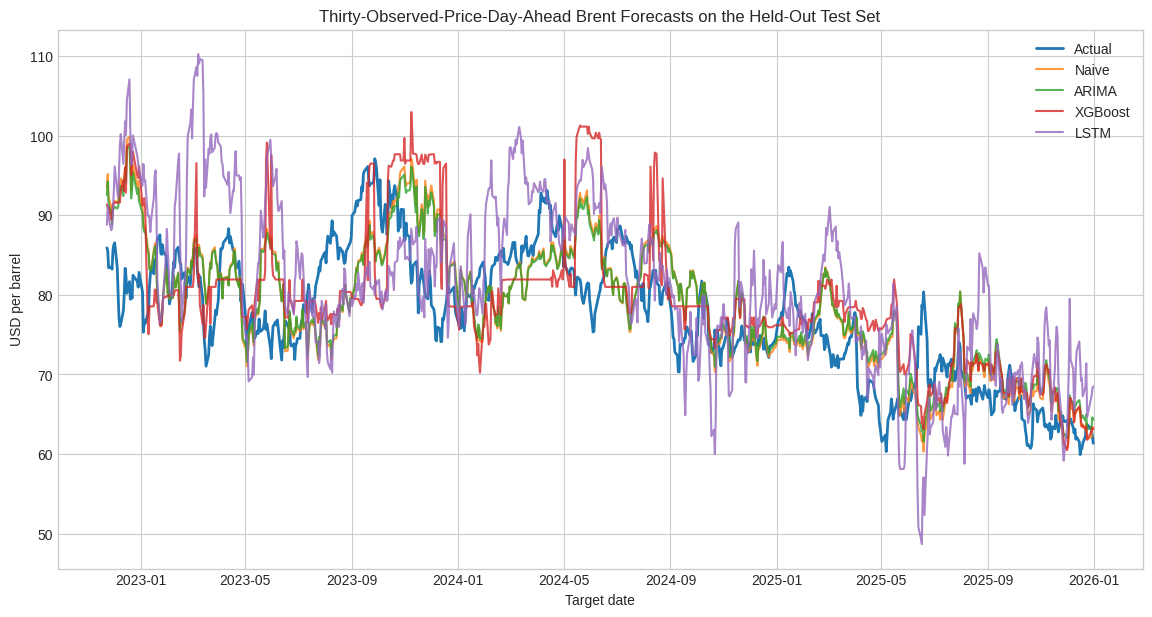

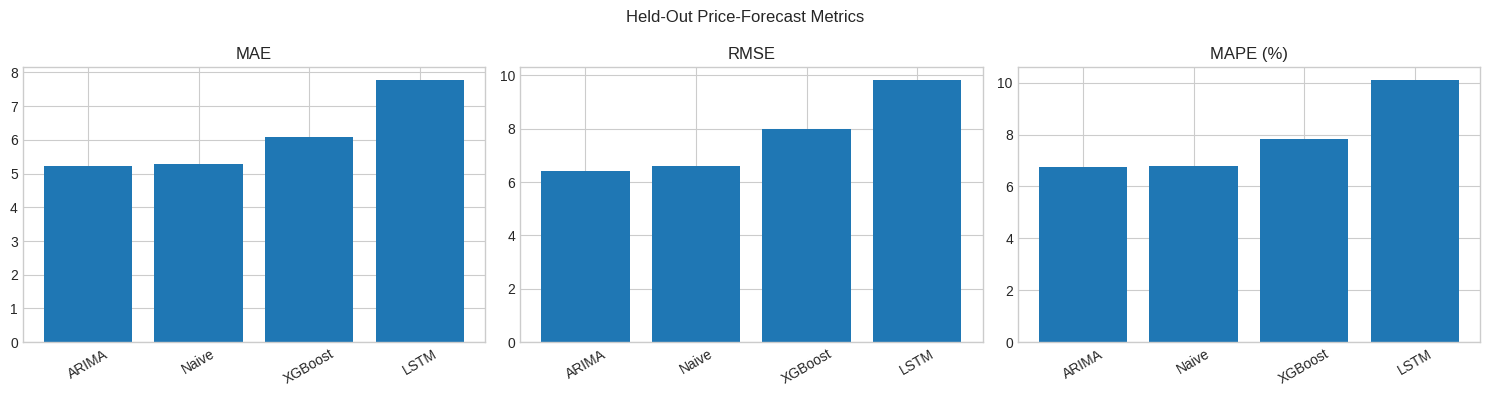

In [21]:
# One aligned price-model comparison on identical test origins and target dates.
comparison_by_origin = pd.DataFrame({
    "target_date": test_df["target_date"],
    "Actual": y_test,
    "Naive": naive_test_pred,
    "ARIMA": arima_test_pred,
    "XGBoost": xgb_test_pred,
    "LSTM": lstm_test_pred,
}).dropna()

assert comparison_by_origin.index.equals(test_df.index)

price_metrics_df = pd.DataFrame([
    evaluate_price_predictions(model_name, comparison_by_origin["Actual"], comparison_by_origin[model_name])
    for model_name in ["Naive", "ARIMA", "XGBoost", "LSTM"]
]).sort_values("RMSE").reset_index(drop=True)

display(price_metrics_df)
print("Lowest test RMSE overall:", price_metrics_df.iloc[0]["Model"])

naive_metrics = price_metrics_df.set_index("Model").loc["Naive"]
nonbaseline_model_comparison = price_metrics_df.loc[
    price_metrics_df["Model"].isin(["ARIMA", "XGBoost", "LSTM"])
].copy()
for metric in ["MAE", "RMSE", "MAPE (%)"]:
    nonbaseline_model_comparison[f"{metric} improvement vs Naive (%)"] = (
        100 * (naive_metrics[metric] - nonbaseline_model_comparison[metric]) / naive_metrics[metric]
    )

display(nonbaseline_model_comparison.sort_values("RMSE"))
best_nonbaseline = nonbaseline_model_comparison.sort_values("RMSE").iloc[0]
print(
    f"Lowest-RMSE non-baseline model: {best_nonbaseline['Model']} "
    f"(RMSE={best_nonbaseline['RMSE']:.3f}; "
    f"{best_nonbaseline['RMSE improvement vs Naive (%)']:+.2f}% vs Naive, where positive is better)."
)

comparison_by_target = comparison_by_origin.set_index("target_date")

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(comparison_by_target.index, comparison_by_target["Actual"], label="Actual", linewidth=2)
for model_name in ["Naive", "ARIMA", "XGBoost", "LSTM"]:
    ax.plot(comparison_by_target.index, comparison_by_target[model_name], label=model_name, alpha=0.8)
ax.set(
    title="Thirty-Observed-Price-Day-Ahead Brent Forecasts on the Held-Out Test Set",
    xlabel="Target date",
    ylabel="USD per barrel",
)
ax.legend()
plt.show()

metrics_long = price_metrics_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "MAPE (%)"],
    var_name="Metric",
    value_name="Value",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, metric in zip(axes, ["MAE", "RMSE", "MAPE (%)"]):
    subset = metrics_long.loc[metrics_long["Metric"] == metric]
    axis.bar(subset["Model"], subset["Value"])
    axis.set_title(metric)
    axis.tick_params(axis="x", rotation=30)
plt.suptitle("Held-Out Price-Forecast Metrics")
plt.tight_layout()
plt.show()


### 3.4 Held-out price-forecast results

All models are evaluated on the same 784 forecast origins and target dates. ARIMA(2,0,0) has the lowest observed test errors: MAE 5.223 USD per barrel, RMSE 6.419 USD per barrel, and MAPE 6.731%. Relative to the naive forecast, these are modest improvements of 1.24%, 2.57%, and 0.85%, respectively. XGBoost and LSTM both underperform persistence, so their additional complexity is not justified by this test period.

The aligned forecast plot shows that every model has difficulty at turning points. XGBoost responds in piecewise steps, while the LSTM frequently overshoots and is the least accurate model. The validation period contains more pronounced shocks than the later test period, which plausibly contributes to the higher validation errors, although this interpretation is not a causal test. Because adjacent 30-step forecast errors overlap, the small ARIMA advantage should be described as the lowest point estimate rather than statistically established superiority.

## 4. GARCH Volatility Modelling

**Conditional heteroscedasticity** means that the variance of returns changes over time conditional on past information. **Volatility clustering** means that large absolute returns tend to be followed by large absolute returns, and quiet periods tend to persist.

A GARCH(1,1) model represents today's conditional variance using a baseline component, the previous squared shock, and the previous conditional variance. This section uses returns from consecutive observed FRED quotes, not interpolated holiday prices. Its one-price-day volatility forecasts are evaluated separately from the 30-price-day forecasts.


,Statistic,Value
0,ARCH-LM,9.704329e+02
1,ARCH-LM p-value,7.851346e-193
2,F statistic,6.164806e+01
3,F-test p-value,1.693858e-218


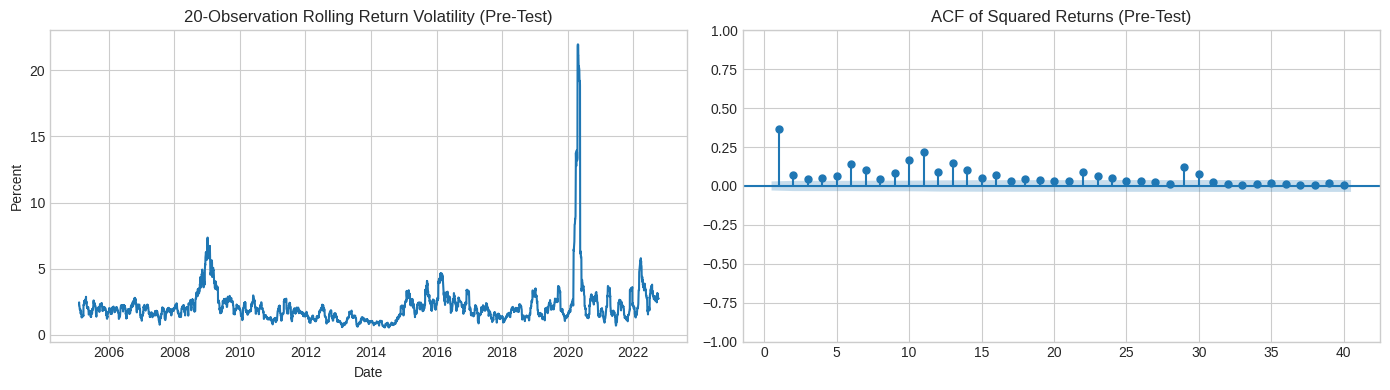

In [22]:
# Volatility-clustering evidence uses the pre-test return series only for formal testing.
garch_train = log_return_pct.loc[log_return_pct.index < test_start].dropna()
garch_test = log_return_pct.loc[log_return_pct.index >= test_start].dropna()

arch_lm_stat, arch_lm_pvalue, arch_f_stat, arch_f_pvalue = het_arch(
    garch_train - garch_train.mean(),
    nlags=20,
)
arch_test_table = pd.DataFrame({
    "Statistic": ["ARCH-LM", "ARCH-LM p-value", "F statistic", "F-test p-value"],
    "Value": [arch_lm_stat, arch_lm_pvalue, arch_f_stat, arch_f_pvalue],
})
display(arch_test_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(garch_train.index, garch_train.rolling(20).std())
axes[0].set(title="20-Observation Rolling Return Volatility (Pre-Test)", xlabel="Date", ylabel="Percent")
plot_acf(garch_train.pow(2), lags=40, zero=False, ax=axes[1])
axes[1].set_title("ACF of Squared Returns (Pre-Test)")
plt.tight_layout()
plt.show()


In [23]:
# A single justified GARCH(1,1) with Student-t innovations.
garch_specification = arch_model(
    garch_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t",
    rescale=False,
)
garch_result = garch_specification.fit(disp="off")
print(garch_result.summary())

garch_params = garch_result.params
omega = float(garch_params.get("omega", np.nan))
alpha = float(garch_params.get("alpha[1]", np.nan))
beta = float(garch_params.get("beta[1]", np.nan))
nu = float(garch_params.get("nu", np.nan))
persistence = alpha + beta

parameter_table = pd.DataFrame({
    "Parameter": ["omega", "alpha[1]", "beta[1]", "alpha + beta", "nu"],
    "Estimate": [omega, alpha, beta, persistence, nu],
    "Interpretation": [
        "Baseline conditional-variance component",
        "Short-run reaction to a new squared shock",
        "Persistence of previous conditional variance",
        "Overall volatility persistence",
        "Student-t tail thickness; lower values imply heavier tails",
    ],
})
display(parameter_table)

if persistence < 1:
    long_run_volatility = sqrt(omega / (1 - persistence))
    print(f"Finite long-run volatility per observed-price interval: {long_run_volatility:.4f}%")
else:
    print("alpha + beta is at least one; finite long-run variance is not supported.")


                        Constant Mean - GARCH Model Results                         
Dep. Variable:               log_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9487.81
Distribution:      Standardized Student's t   AIC:                           18985.6
Method:                  Maximum Likelihood   BIC:                           19017.7
                                              No. Observations:                 4500
Date:                      Sun, Jul 19 2026   Df Residuals:                     4499
Time:                              05:50:01   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

,Parameter,Estimate,Interpretation
0,omega,0.059428,Baseline conditional-variance component
1,alpha[1],0.085264,Short-run reaction to a new squared shock
2,beta[1],0.906976,Persistence of previous conditional variance
3,alpha + beta,0.992239,Overall volatility persistence
4,nu,6.101093,Student-t tail thickness; lower values imply h...


Finite long-run volatility per observed-price interval: 2.7672%


,Metric,Value
0,MAE: forecast volatility vs absolute return,1.095877
1,RMSE: forecast volatility vs absolute return,1.330768
2,MAE: forecast variance vs squared return,4.011524
3,Correlation: volatility vs absolute return,0.176429
4,Correlation: variance vs squared return,0.153086


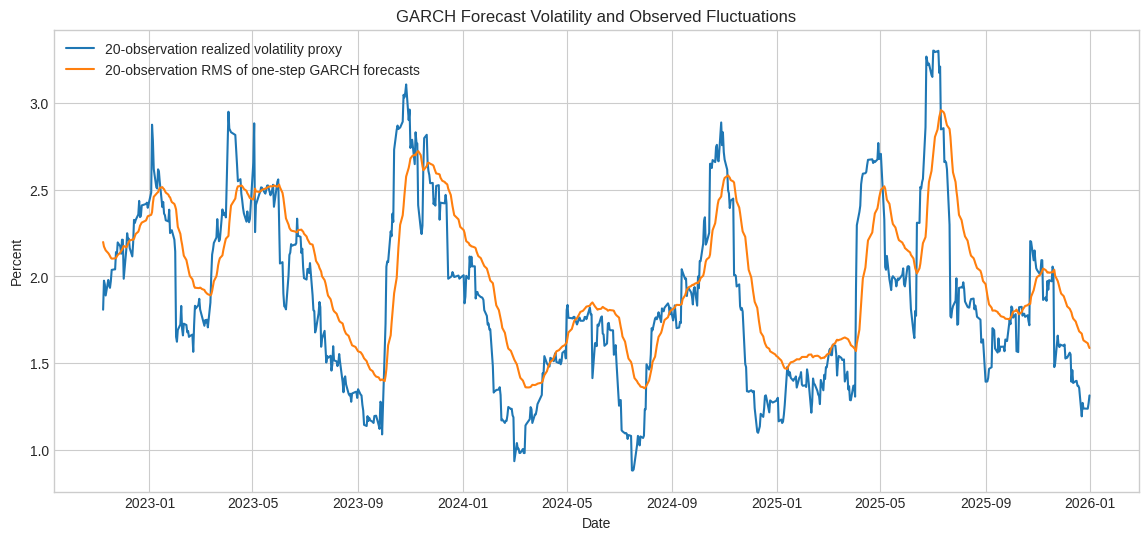

In [24]:
def rolling_garch_one_step(full_returns, forecast_dates, refit_every=20):
    forecast_dates = pd.DatetimeIndex(forecast_dates).sort_values()
    forecast_variances = []
    fitted_params = None

    for step, forecast_date in enumerate(forecast_dates):
        history = full_returns.loc[full_returns.index < forecast_date].dropna()
        model = arch_model(
            history,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="t",
            rescale=False,
        )

        if fitted_params is None or step % refit_every == 0:
            result = model.fit(disp="off")
            fitted_params = result.params
        else:
            result = model.fix(fitted_params)

        variance = float(result.forecast(horizon=1, reindex=False).variance.iloc[-1, 0])
        forecast_variances.append(variance)

    return pd.Series(forecast_variances, index=forecast_dates, name="forecast_variance")


garch_forecast_variance = rolling_garch_one_step(
    log_return_pct,
    garch_test.index,
    refit_every=20,
)

garch_evaluation = pd.DataFrame({
    "actual_return": garch_test,
    "absolute_return": garch_test.abs(),
    "squared_return": garch_test.pow(2),
    "forecast_variance": garch_forecast_variance,
})
garch_evaluation["forecast_volatility"] = np.sqrt(garch_evaluation["forecast_variance"])

correlation_abs, _ = pearsonr(
    garch_evaluation["absolute_return"],
    garch_evaluation["forecast_volatility"],
)
correlation_sq, _ = pearsonr(
    garch_evaluation["squared_return"],
    garch_evaluation["forecast_variance"],
)

garch_metrics_df = pd.DataFrame({
    "Metric": [
        "MAE: forecast volatility vs absolute return",
        "RMSE: forecast volatility vs absolute return",
        "MAE: forecast variance vs squared return",
        "Correlation: volatility vs absolute return",
        "Correlation: variance vs squared return",
    ],
    "Value": [
        mean_absolute_error(garch_evaluation["absolute_return"], garch_evaluation["forecast_volatility"]),
        sqrt(mean_squared_error(garch_evaluation["absolute_return"], garch_evaluation["forecast_volatility"])),
        mean_absolute_error(garch_evaluation["squared_return"], garch_evaluation["forecast_variance"]),
        correlation_abs,
        correlation_sq,
    ],
})
display(garch_metrics_df)

garch_evaluation["realized_volatility_20"] = np.sqrt(
    garch_evaluation["squared_return"].rolling(20).mean()
)
garch_evaluation["forecast_volatility_20"] = np.sqrt(
    garch_evaluation["forecast_variance"].rolling(20).mean()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    garch_evaluation.index,
    garch_evaluation["realized_volatility_20"],
    label="20-observation realized volatility proxy",
)
ax.plot(
    garch_evaluation.index,
    garch_evaluation["forecast_volatility_20"],
    label="20-observation RMS of one-step GARCH forecasts",
)
ax.set(title="GARCH Forecast Volatility and Observed Fluctuations", xlabel="Date", ylabel="Percent")
ax.legend()
plt.show()


### 4.1 Estimated dynamics and forecast evidence

The pre-test ARCH-LM result (statistic 970.433, \(p=7.85\times10^{-193}\)) and the positive squared-return autocorrelations provide strong evidence of conditional heteroscedasticity. In the Student-t GARCH(1,1), \(\alpha=0.0853\) measures the immediate response to a new shock and \(\beta=0.9070\) shows that previous variance dominates the next estimate. Their sum, 0.9922, indicates very slow decay of volatility shocks. The estimated Student-t degrees of freedom, \(\nu=6.10\), is consistent with heavier tails than a Gaussian model.

The expanding one-step forecasts have an MAE of 1.096 and RMSE of 1.331 percentage points against absolute returns. Correlations are only 0.176 with absolute returns and 0.153 with squared returns. The smoothed comparison plot follows broad volatility regimes but reacts incompletely to abrupt spikes. GARCH therefore provides interpretable conditional-risk dynamics, but this evaluation does not demonstrate strong point-by-point predictive association.

### 4.2 Strengths and limitations

GARCH is parsimonious and makes shock response, persistence, and time-varying conditional variance explicit; Student-t innovations accommodate heavy-tailed returns. However, true volatility is latent, so absolute and squared returns are noisy proxies. GARCH(1,1) also assumes fixed parameters and a symmetric response to positive and negative shocks, and it does not predict price direction or level.

## 5. Discussion and Critical Reflection

ARIMA gives the lowest held-out price errors, but its advantage over persistence is small. The selected \(d=0\) specification also requires caution because the level ADF test does not support stationarity and stationarity constraints were relaxed during estimation. Its result is best viewed as validation-selected forecast performance, not evidence for a stable price-generating process. XGBoost captures nonlinear interactions among temporal features but extrapolates poorly outside familiar price regimes. The LSTM can represent nonlinear sequences, yet here it is less accurate, more computationally demanding, and less interpretable.

For practical use, the price forecasts are planning benchmarks rather than trading signals. GARCH is a complementary risk-monitoring tool for hedging context and scenario analysis, not a competitor in the price-error ranking. The analysis assumes that historical relationships remain informative, that an observed-price-day time scale is acceptable, and that a univariate information set is sufficient. It omits inventories, production decisions, futures curves, exchange rates, macroeconomic indicators, and geopolitical information. A single split, overlapping 30-step errors, compact tuning grids, lack of forecast intervals, and changing market regimes further limit generalisation.

Operational use should include uncertainty communication, human review, and regular monitoring. These forecasts are not financial advice and should not be used alone for automated trading, hedging, budgeting, or policy decisions. Useful extensions would be rolling evaluation across multiple regimes, carefully dated exogenous variables, formal uncertainty intervals, and a volatility benchmark evaluated with a loss function designed for latent variance.

## 6. Conclusion

The analysis finds strong trend and irregular variation, weak seasonality, non-stationary price levels, and pronounced volatility clustering. ARIMA(2,0,0) records the lowest held-out price errors but improves only marginally on persistence, while XGBoost and LSTM do not justify their added complexity in this period. Student-t GARCH(1,1) identifies heavy tails and highly persistent conditional variance, although its association with realized-return proxies is weak. Taken together, the models are most defensible as transparent planning and risk benchmarks rather than autonomous decision systems.
